In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from itertools import product
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [266]:
df = pd.read_csv(r"C:\Users\jefft\OneDrive - Concordia University, St. Paul\NFL data\Career_Stats_Receiving.csv")
df

,Player Id,Name,Position,Year,Team,Games Played,Receptions,Receiving Yards,Yards Per Reception,Yards Per Game,Longest Reception,Receiving TDs,Receptions Longer than 20 Yards,Receptions Longer than 40 Yards,First Down Receptions,Fumbles
0,fredevans/2513736,"Evans, Fred",NaN,1948,Chicago Bears,3,1,-2,-2.0,-0.7,--,0,--,--,--,--
1,fredevans/2513736,"Evans, Fred",NaN,1948,Chicago Rockets,0,--,--,--,0.0,--,--,--,--,--,--
2,fredevans/2513736,"Evans, Fred",NaN,1947,Chicago Rockets,0,--,--,--,0.0,--,--,--,--,--,--
3,fredevans/2513736,"Evans, Fred",NaN,1947,Buffalo Bills,0,--,--,--,0.0,--,--,--,--,--,--
4,fredevans/2513736,"Evans, Fred",NaN,1946,Cleveland Browns,0,--,--,--,0.0,--,--,--,--,--,--
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18123,billanderson/2508534,"Anderson, Bill",NaN,1961,Washington Redskins,14,40,637,15.9,45.5,--,0,--,--,--,--
18124,billanderson/2508534,"Anderson, Bill",NaN,1960,Washington Redskins,12,38,488,12.8,40.7,--,3,--,--,--,--
18125,billanderson/2508534,"Anderson, Bill",NaN,1959,Washington Redskins,11,35,734,21.0,66.7,--,6,--,--,--,--
18126,billanderson/2508534,"Anderson, Bill",NaN,1958,Washington Redskins,12,18,396,22.0,33.0,--,2,--,--,--,--


In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18128 entries, 0 to 18127
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Player Id                        18128 non-null  object 
 1   Name                             18128 non-null  object 
 2   Position                         2400 non-null   object 
 3   Year                             18128 non-null  int64  
 4   Team                             18128 non-null  object 
 5   Games Played                     18128 non-null  int64  
 6   Receptions                       18128 non-null  object 
 7   Receiving Yards                  18128 non-null  object 
 8   Yards Per Reception              18128 non-null  object 
 9   Yards Per Game                   18128 non-null  float64
 10  Longest Reception                18128 non-null  object 
 11  Receiving TDs                    18128 non-null  object 
 12  Receptions Longer 

In [268]:
data_cleaned = df.dropna()
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 92 to 18118
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Player Id                        2400 non-null   object 
 1   Name                             2400 non-null   object 
 2   Position                         2400 non-null   object 
 3   Year                             2400 non-null   int64  
 4   Team                             2400 non-null   object 
 5   Games Played                     2400 non-null   int64  
 6   Receptions                       2400 non-null   object 
 7   Receiving Yards                  2400 non-null   object 
 8   Yards Per Reception              2400 non-null   object 
 9   Yards Per Game                   2400 non-null   float64
 10  Longest Reception                2400 non-null   object 
 11  Receiving TDs                    2400 non-null   object 
 12  Receptions Longer than 

In [269]:
data_cleaned['Longest Reception'] = data_cleaned['Longest Reception'].str.replace('T','')

C:\Users\jefft\AppData\Local\Temp\ipykernel_27316\898097017.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Longest Reception'] = data_cleaned['Longest Reception'].str.replace('T','')


In [270]:
data_cleaned['Longest Reception'] = data_cleaned['Longest Reception'].str.replace('F','')

C:\Users\jefft\AppData\Local\Temp\ipykernel_27316\2496373360.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Longest Reception'] = data_cleaned['Longest Reception'].str.replace('F','')


In [271]:
data_cleaned['Longest Reception'] = pd.to_numeric(data_cleaned['Longest Reception'], errors='coerce', downcast='integer')
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 92 to 18118
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Player Id                        2400 non-null   object 
 1   Name                             2400 non-null   object 
 2   Position                         2400 non-null   object 
 3   Year                             2400 non-null   int64  
 4   Team                             2400 non-null   object 
 5   Games Played                     2400 non-null   int64  
 6   Receptions                       2400 non-null   object 
 7   Receiving Yards                  2400 non-null   object 
 8   Yards Per Reception              2400 non-null   object 
 9   Yards Per Game                   2400 non-null   float64
 10  Longest Reception                1932 non-null   float64
 11  Receiving TDs                    2400 non-null   object 
 12  Receptions Longer than 

C:\Users\jefft\AppData\Local\Temp\ipykernel_27316\3838507232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Longest Reception'] = pd.to_numeric(data_cleaned['Longest Reception'], errors='coerce', downcast='integer')


In [272]:
data_cleaned=data_cleaned.drop(['Player Id', 'Name', 'Team', 'Year','Games Played','Fumbles'], axis=1)

In [273]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 92 to 18118
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Position                         2400 non-null   object 
 1   Receptions                       2400 non-null   object 
 2   Receiving Yards                  2400 non-null   object 
 3   Yards Per Reception              2400 non-null   object 
 4   Yards Per Game                   2400 non-null   float64
 5   Longest Reception                1932 non-null   float64
 6   Receiving TDs                    2400 non-null   object 
 7   Receptions Longer than 20 Yards  2400 non-null   object 
 8   Receptions Longer than 40 Yards  2400 non-null   object 
 9   First Down Receptions            2400 non-null   object 
dtypes: float64(2), object(8)
memory usage: 206.2+ KB


In [274]:
data_cleaned=data_cleaned.dropna()
data_cleaned['Position'].value_counts()


Position
WR    750
RB    520
TE    513
FB     78
QB     54
CB      5
DE      4
FS      3
DB      3
SS      1
LB      1
Name: count, dtype: int64

In [275]:
dropping_outliers = ['CB','DE','FS','DB','SS','LB']
data_cleaned = data_cleaned[~data_cleaned['Position'].isin(dropping_outliers)]
data_cleaned['Position'].value_counts()

Position
WR    750
RB    520
TE    513
FB     78
QB     54
Name: count, dtype: int64

In [276]:
LabelEncoder = LabelEncoder()
data_cleaned['Position'] = LabelEncoder.fit_transform(data_cleaned['Position'])
data_cleaned['Receptions'] = LabelEncoder.fit_transform(data_cleaned['Receptions'])
data_cleaned['Receiving Yards'] = LabelEncoder.fit_transform(data_cleaned['Receiving Yards'])
data_cleaned['Yards Per Reception'] = LabelEncoder.fit_transform(data_cleaned['Yards Per Reception'])
data_cleaned['Receiving TDs'] = LabelEncoder.fit_transform(data_cleaned['Receiving TDs'])
data_cleaned['Receptions Longer than 20 Yards'] = LabelEncoder.fit_transform(data_cleaned['Receptions Longer than 20 Yards'])
data_cleaned['Receptions Longer than 40 Yards'] = LabelEncoder.fit_transform(data_cleaned['Receptions Longer than 40 Yards'])
data_cleaned['First Down Receptions'] = LabelEncoder.fit_transform(data_cleaned['First Down Receptions'])


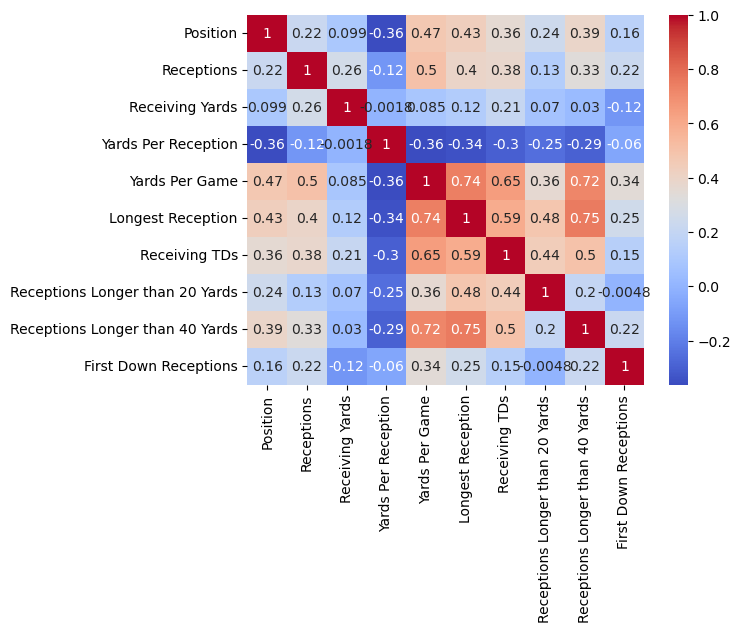

In [277]:
correlation_map = sns.heatmap(data_cleaned.corr(numeric_only=True), cmap="coolwarm", annot=True)

In [278]:
select = SelectKBest(score_func=f_regression, k='all')
x_select = data_cleaned.drop("Position", axis=1)
y_select = data_cleaned['Position']
select.fit(x_select,y_select)
feature_scores = pd.DataFrame({'Feature': x_select.columns, 'Score': select.scores_})
print(feature_scores.sort_values(by='Score', ascending=False))

                           Feature       Score
3                   Yards Per Game  540.364324
4                Longest Reception  436.984787
7  Receptions Longer than 40 Yards  340.936443
2              Yards Per Reception  288.006441
5                    Receiving TDs  282.927383
6  Receptions Longer than 20 Yards  121.516711
0                       Receptions   97.915963
8            First Down Receptions   52.348952
1                  Receiving Yards   19.012075


In [279]:
y = data_cleaned['Position']
data_cleaned = data_cleaned.drop(['Receiving Yards','First Down Receptions','Receptions','Position'], axis=1)

In [ ]:
normalize = StandardScaler()
data_cleaned = normalize.fit_transform(data_cleaned)
x = data_cleaned
y = y.values.reshape(-1,1)
print(data_cleaned)
print(data_cleaned.shape)


AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [281]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)
print(x_train.shape, x_val.shape, x_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(1149, 6) (383, 6) (383, 6)
(1149, 1) (383, 1) (383, 1)


In [282]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [283]:
class NFLDataset(Dataset):
    def __init__(self, x, y, forest_pred):
        self.x = torch.tensor(x, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.long).to(device)
        self.forest_pred = torch.tensor(forest_pred, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.forest_pred[idx]

In [284]:
forest_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

forest = RandomForestClassifier()
grid_search = GridSearchCV(forest, forest_param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train.ravel())
forest = grid_search.best_estimator_
print("Best Random Forest Parameters: ", grid_search.best_params_)
print("Best Random Forest Accuracy: ", grid_search.best_score_)


Best Random Forest Parameters:  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best Random Forest Accuracy:  0.5570001898614011


In [285]:
forest_pred_train = forest.predict(x_train)
print("forest_pred_train: ", forest_pred_train)
forest_pred_val = forest.predict(x_val)
print("forest_pred_val: ", forest_pred_val)
forest_pred_test = forest.predict(x_test)
print("forest_pred_test: ", forest_pred_test)

forest_pred_train:  [2 2 2 ... 3 3 2]
forest_pred_val:  [3 2 2 4 4 3 4 2 4 4 4 3 2 3 4 2 4 4 2 3 3 2 4 4 2 2 4 4 2 3 2 3 3 4 4 4 4
 2 1 4 2 2 2 3 3 2 2 4 3 4 3 4 1 2 2 4 4 2 2 3 3 4 4 2 3 4 2 2 2 3 3 3 3 4
 4 4 4 2 4 3 2 3 3 2 3 4 4 4 2 3 2 3 3 2 3 2 4 0 2 3 2 4 2 4 4 2 4 3 0 2 3
 3 2 4 4 2 3 4 2 2 4 3 3 3 2 4 3 4 4 2 2 4 4 3 4 2 4 4 4 4 4 3 4 3 4 2 2 3
 4 2 3 2 2 4 4 2 4 2 2 1 1 2 4 3 3 3 4 4 4 3 2 2 2 4 3 2 4 2 2 3 3 4 2 2 3
 1 3 2 3 2 4 4 4 2 4 4 4 4 4 3 2 3 2 2 2 2 3 3 3 4 2 3 2 4 4 4 2 4 2 3 4 4
 3 4 4 2 2 2 2 4 4 4 2 4 2 2 4 4 2 3 2 3 4 4 2 4 2 2 4 4 4 4 1 4 2 4 2 2 4
 4 4 4 3 4 3 2 2 3 3 2 4 2 4 3 4 4 4 4 4 3 2 4 4 3 3 4 4 2 2 2 2 4 3 3 1 4
 4 3 4 4 2 3 4 4 2 2 2 3 2 4 4 4 3 2 2 2 4 4 3 3 4 4 3 3 4 3 4 4 3 2 2 2 4
 2 4 3 4 2 3 4 4 3 2 3 3 2 4 1 4 4 2 2 2 4 1 4 4 2 3 3 2 3 2 3 2 2 1 4 2 4
 4 2 4 2 3 1 3 2 2 3 4 2 4]
forest_pred_test:  [2 2 3 4 2 2 2 4 4 3 4 2 2 3 3 3 3 3 4 2 2 2 4 3 4 4 3 4 3 3 2 4 3 2 4 2 2
 4 2 4 4 3 4 4 2 3 4 4 3 4 4 4 4 4 4 3 2 2 3 2 4 2 4 3 2 4 2 4 4 2 2 2 2

In [292]:
class NFLModelWithForest(nn.Module):
    def __init__(self, input_size, forest_output_size, hidden_size1, hidden_size2):
        super(NFLModelWithForest, self).__init__()
        self.fc1 = nn.Linear(input_size + forest_output_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, 5)
        self.relu = nn.ReLU()

    def forward(self, x, forest_pred):
        x = torch.cat((x, forest_pred.unsqueeze(1)), dim=1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [287]:
hyper_grid_loop = {
    'hidden_size1': [16, 32, 64],
    'hidden_size2': [16, 32, 64],
    'learning_rate': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128],
    'epochs': [50, 100, 200]
}

In [288]:
train_dataset = NFLDataset(x_train, y_train, forest_pred_train)
valid_dataset = NFLDataset(x_val, y_val, forest_pred_val)
test_dataset = NFLDataset(x_test, y_test, forest_pred_test)

best_model = None
best_loss = float('inf')
best_hyperparameters = None
input_size = x_train.shape[1]



In [295]:
for hidden_size1, hidden_size2, learning_rate, batch_size, epochs in product(*hyper_grid_loop.values()):
    forest_output_size = 1
    model = NFLModelWithForest(input_size,forest_output_size, hidden_size1,hidden_size2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for x_batch, y_batch, forest_pred_batch in train_loader:
            optimizer.zero_grad()
            y_batch = y_batch.view(-1)
            y_pred = model(x_batch, forest_pred_batch)
            loss = criterion(y_pred, y_batch.long()) 
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)    

        model.eval()
        with torch.no_grad():
            valid_loss = 0
            for x_batch, y_batch, forest_pred_batch in valid_loader:
                y_batch = y_batch.view(-1)
                y_pred = model(x_batch, forest_pred_batch)
                valid_loss += criterion(y_pred, y_batch)
            avg_valid_loss = valid_loss / len(valid_loader)
        print(f"Epoch: {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")
        print(f"Current Parameters: hidden_size1={hidden_size1}, hidden_size2={hidden_size2}, learning_rate={learning_rate}, batch_size={batch_size}, epochs={epochs}")
        
        if valid_loss < best_loss:
            best_model = model
            best_loss = valid_loss
            best_hyperparameters = (hidden_size1, hidden_size2, learning_rate, batch_size, epochs)
            
print(f"Best Validation Loss: {best_loss:.4f}")
print(f"Best Hyperparameters: hidden_size1={best_hyperparameters[0]}, hidden_size2={best_hyperparameters[1]}, learning_rate={best_hyperparameters[2]}, batch_size={best_hyperparameters[3]}, epochs={best_hyperparameters[4]}")

Epoch: 1/50, Training Loss: 1.6023, Validation Loss: 1.5288
Current Parameters: hidden_size1=16, hidden_size2=16, learning_rate=0.001, batch_size=32, epochs=50
Epoch: 2/50, Training Loss: 1.4588, Validation Loss: 1.3831
Current Parameters: hidden_size1=16, hidden_size2=16, learning_rate=0.001, batch_size=32, epochs=50
Epoch: 3/50, Training Loss: 1.2814, Validation Loss: 1.2416
Current Parameters: hidden_size1=16, hidden_size2=16, learning_rate=0.001, batch_size=32, epochs=50
Epoch: 4/50, Training Loss: 1.1534, Validation Loss: 1.1662
Current Parameters: hidden_size1=16, hidden_size2=16, learning_rate=0.001, batch_size=32, epochs=50
Epoch: 5/50, Training Loss: 1.0907, Validation Loss: 1.1190
Current Parameters: hidden_size1=16, hidden_size2=16, learning_rate=0.001, batch_size=32, epochs=50
Epoch: 6/50, Training Loss: 1.0495, Validation Loss: 1.0885
Current Parameters: hidden_size1=16, hidden_size2=16, learning_rate=0.001, batch_size=32, epochs=50
Epoch: 7/50, Training Loss: 1.0144, Vali

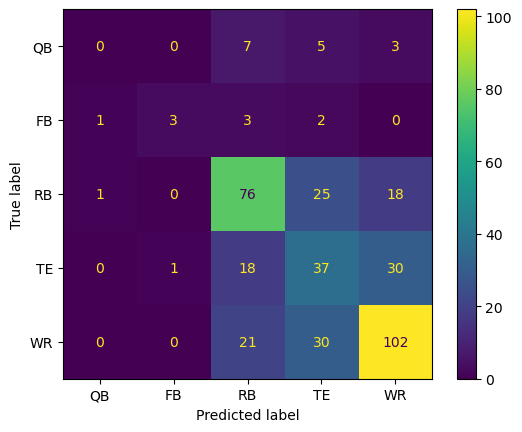

Accuracy: 0.5692


In [302]:
model.eval()
predictions = []
true_class = []
with torch.no_grad():
    for x_batch, y_batch, forest_pred_batch in test_loader:
        y_batch = y_batch.view(-1)  
        y_pred = model(x_batch, forest_pred_batch)
        predictions.extend(torch.argmax(y_pred, dim=1).cpu().numpy())
        true_class.extend(y_batch.cpu().numpy())

original_class_labels = ['QB', 'FB', 'RB', 'TE', 'WR']
class_idx_to_label = {idx: label for idx, label in enumerate(original_class_labels)}

predictions_labels = [class_idx_to_label[pred] for pred in predictions]
true_class_labels = [class_idx_to_label[label] for label in true_class]
# Confusion Matrix
cm = confusion_matrix(true_class_labels, predictions_labels, labels=original_class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=original_class_labels)
disp.plot()
plt.show()

correct_predictions = sum(p == t for p, t in zip(predictions_labels, true_class_labels))
accuracy = correct_predictions / len(true_class_labels)
print(f"Accuracy: {accuracy:.4f}")